Loaded generated-nets/hist2d_ba_avgOverSeeds_norm.npy shape (60, 100)
Loaded generated-nets/hist2d_er_avgOverSeeds_norm.npy shape (60, 100)
Loaded generated-nets/hist2d_conf_avgOverSeeds_norm.npy shape (60, 100)
Loaded generated-nets/hist2d_s1h2_avgOverSeeds_norm.npy shape (60, 100)


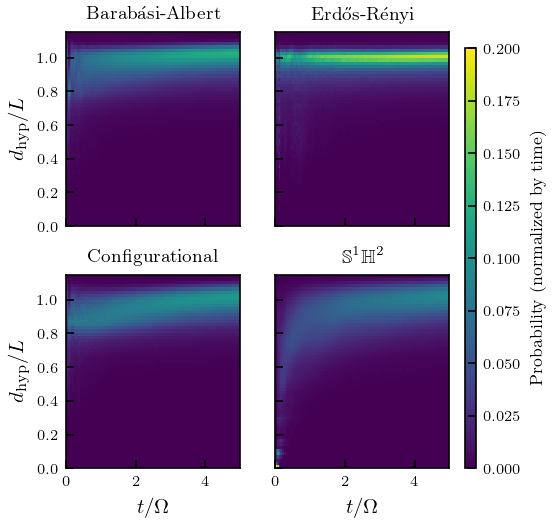

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pipeline.init as init

init.configure_matplotlib()

# =============================================================================
# Configuración
# =============================================================================
MODELS = ["ba", "er", "conf", "s1h2"]
MODEL_NAMES = ["Barabási-Albert", "Erdős-Rényi", "Configurational", r"$\mathbb{S}^1\mathbb{H}^2$"]

DIST_MIN, DIST_MAX = 0.0, 1.15
TIME_MIN, TIME_MAX = 0.0, 5.0
NUM_DIST_BINS = 60
NUM_TIME_BINS = 100

dist_bins = np.linspace(DIST_MIN, DIST_MAX, NUM_DIST_BINS + 1)
time_bins = np.linspace(TIME_MIN, TIME_MAX, NUM_TIME_BINS + 1)

# Dimensiones para artículo de dos columnas (ancho de columna ~3.5 pulgadas)
fig_width = 3.5
fig_height = 3.5   # relación 1:1 porque es 2x2

# =============================================================================
# Función para dibujar mapa de calor en un subplot
# =============================================================================
def draw_heatmap(ax, H_norm, dist_bins, time_bins, title, vmin, vmax):
    dist_centers = (dist_bins[:-1] + dist_bins[1:]) / 2
    time_centers = (time_bins[:-1] + time_bins[1:]) / 2
    im = ax.pcolormesh(time_centers, dist_centers, H_norm,
                       shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    return im

# =============================================================================
# Cargar datos
# =============================================================================
data = {}
for model in MODELS:
    npy_file = f"generated-nets/hist2d_{model}_avgOverSeeds_norm.npy"
    if not os.path.exists(npy_file):
        print(f"File not found: {npy_file} – skipping {model}")
        data[model] = None
    else:
        H_norm = np.load(npy_file)
        print(f"Loaded {npy_file} shape {H_norm.shape}")
        data[model] = H_norm

if any(v is None for v in data.values()):
    print("Missing data for some model. Exiting.")
    exit(1)

# =============================================================================
# Crear figura 2x2 con ejes compartidos
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(fig_width, fig_height),
                         dpi=150, sharex=True, sharey=True)
ax_flat = axes.flatten()

vmin, vmax = 0, 0.2

# Dibujar subplots
for ax, model, name in zip(ax_flat, MODELS, MODEL_NAMES):
    im = draw_heatmap(ax, data[model], dist_bins, time_bins,
                      title=name, vmin=vmin, vmax=vmax)

# Configurar etiquetas solo en la fila inferior y columna izquierda
for ax in axes[-1, :]:   # fila inferior (segunda fila)
    ax.set_xlabel(r"$t/\Omega$")
for ax in axes[:, 0]:    # columna izquierda
    ax.set_ylabel(r"$d_\text{hyp}/L$")

# Opcional: mejorar el formato de los números en los ejes
for ax in ax_flat:
    ax.tick_params(axis='both', which='major', labelsize=7)

# Ajustar límites (ya compartidos, pero por claridad)
for ax in ax_flat:
    ax.set_xlim(TIME_MIN, TIME_MAX)
    ax.set_ylim(DIST_MIN, DIST_MAX)

# Añadir barra de color evitando superposición: reservar espacio a la derecha
plt.subplots_adjust(right=0.85, left=0.12, bottom=0.12, top=0.95, wspace=0.2, hspace=0.25)
cbar_ax = fig.add_axes([0.88, 0.12, 0.02, 0.8])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Probability (normalized by time)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

# Guardar figura
# plt.savefig("heatmap_all_models.png", dpi=300, bbox_inches='tight')
plt.savefig("figs/heatmap_all_models.pdf", bbox_inches='tight')
plt.show()